<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1692 entries, 0 to 1691
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1692 non-null   object 
 1   Open       1692 non-null   float64
 2   High       1692 non-null   float64
 3   Low        1692 non-null   float64
 4   Close      1692 non-null   float64
 5   Volume     1692 non-null   int64  
 6   Adj Close  1692 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 92.7+ KB
None
              Open         High          Low        Close        Volume  \
count  1692.000000  1692.000000  1692.000000  1692.000000  1.692000e+03   
mean    132.441572   134.769698   129.996223   132.428658  4.270741e+06   
std      94.309923    95.694914    92.855227    94.313187  4.295971e+06   
min      16.139999    16.629999    14.980000    15.800000  1.185000e+05   
25%      30.000000    30.650000    29.215000    29.884999  1.194350e+06   
50%     156.3349

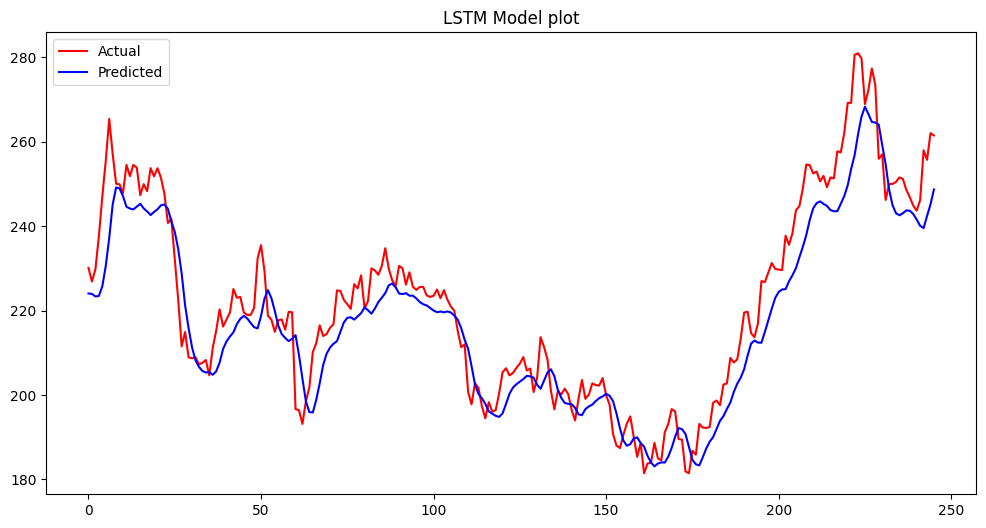

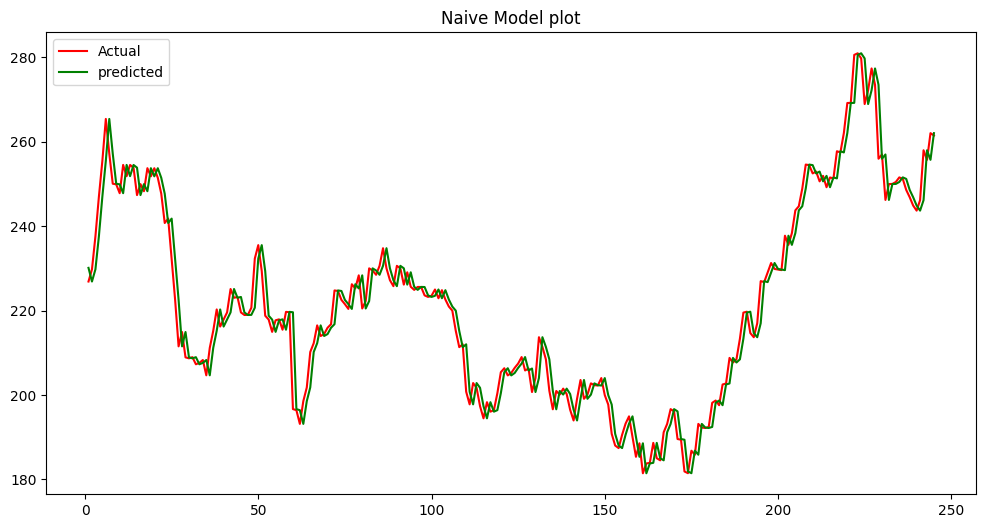

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
LSTM and Naive Minimum, Maximum and Mean Errors
    Model  Minimum Error  Maximum Error  Mean Error
0   LSTM     -17.527053      28.265335    4.566179
1  Naive     -22.949997      11.830002    0.128041

ADF statistic and P Value :
    ADF statistic   P value
0      -0.813733  0.815055

LSTM and Naive Model Comparision :
    Model       MAE      RMSE      MAPE
0   LSTM  6.528865  8.212768  2.874237
1  Naive  3.369101  4.650341  1.522911

LSTM and Naive Prediction Comparision :
               Model  Predicted Price
0   LSTM Prediction       251.354385
1  Naive Prediction       261.500000


In [2]:
# 1. Data Loading and Initial Exploration
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
df = pd.read_csv(r"D:\Stock Price Analysis Data Science Project\Tesla Stock Price.csv")
df_model = df.copy()

# 2. Exploratory Data Analysis (EDA)
print(df_model.info())
print(df_model.describe())
print(df_model.isnull().sum())

# Data Cleaning and Transformation
df_model = df_model.drop("Adj Close", axis = 1)

df_model = df_model[["Date","Volume","Open","High","Low","Close"]]
df_model["Date"] = pd.to_datetime(df_model["Date"], format = "mixed")

col = ["Open","High","Low","Close"]
df_model[col] = df_model[col].astype(float)
df_model["Volume"] = df_model["Volume"].astype(int)

# 3. Outlier Detection Using IQR
df_model["Return"] = df_model["Close"].pct_change()
Q1 = df_model["Return"].quantile(0.25)
Q3 = df_model["Return"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outlier = df_model[(df_model["Return"] < lower) | (df_model["Return"] > upper)]

# Find Outlier Percentage
print("Number of Outliers:", len(outlier))
outliers_percentage = (len(outlier) / len(df_model) * 100)
print(f"Outlier Percentage: {outliers_percentage:.2f}%")

# 4. Rolling Statistics Analysis
rolling_mean = df_model["Close"].rolling(30).mean()
rolling_std  = df_model["Close"].rolling(30).std()

# 5. Stationarity Testing (ADF Test)
from statsmodels.tsa.stattools import adfuller
result = adfuller(df_model["Close"])
Stationarity = pd.DataFrame({"ADF statistic" : [result[0]],
                             "P value"       : [result[1]]})

# 6. Data Preprocessing and Feature Scaling
from sklearn.preprocessing import MinMaxScaler
train_end = int(len(df_model) * 0.7)
scaler = MinMaxScaler()
train_data = df_model[["Close"]][:train_end]
scaler.fit(train_data)
scaled_data = scaler.transform(df_model[["Close"]])

# 7. Sliding Window Creation
X = []
y = []
for i in range(60, len(scaled_data)):
    X.append(scaled_data[i-60:i])
    y.append(scaled_data[i])

'''70% Train
   15% Validation
   15% Test'''

# 8. LSTM Model Development
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

model = Sequential()
model.add(LSTM(50,
               return_sequences = True,
               input_shape = (60,1)))
model.add(Dropout(0.2))
model.add(LSTM(50))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer = "adam",
               loss = "mae")

X = np.array(X)
y = np.array(y)

# 9. Model Training and Validation
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)
X_train = X[:train_size]
X_val = X[train_size : train_size + val_size]
X_test = X[train_size + val_size :]

y_train = y[:train_size]
y_val = y[train_size : train_size + val_size]
y_test = y[train_size + val_size :]

# Training
history = model.fit(X_train,
                    y_train,
                    epochs=50,
                    batch_size = 32,
                    validation_data = (X_val,y_val))

# 10. LSTM Prediction and Evaluation
y_pred_lstm = model.predict(X_test)

#Inverse Scaling
y_pred_lstm = scaler.inverse_transform(y_pred_lstm)
y_test_lstm = scaler.inverse_transform(y_test)

# Model Evaluation
# MAE, MSE, RMSE, MAPE
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
lstm_mae = mean_absolute_error(y_test_lstm, y_pred_lstm)
lstm_mse = mean_squared_error(y_test_lstm, y_pred_lstm)
lstm_rmse = np.sqrt(lstm_mse)
lstm_mape = np.mean(np.abs(y_test_lstm - y_pred_lstm) / y_test_lstm) * 100

# 11. Error Detection
lstm_error = (y_test_lstm - y_pred_lstm)
naive_error = (y_test_naive - y_pred_naive)
Errors = pd.DataFrame({"Model" : ["LSTM","Naive"],
                       "Minimum Error" : [np.min(lstm_error), np.min(naive_error)],
                       "Maximum Error" : [np.max(lstm_error), np.max(naive_error)],
                       "Mean Error" : [np.mean(lstm_error), np.mean(naive_error)]
                      })

# 12. Baseline Model Comparison (Naive Forecast)
y_test_naive = pd.Series(y_test_lstm.flatten())
y_pred_naive = y_test_naive.shift(1)

# Baseline Model Comparison and Evaluation
# Remove NaN line
y_pred_naive = y_pred_naive.dropna()
y_test_naive = y_test_naive[1:]

# Model Evaluation
# MAE, MSE, RMSE, MAPE
naive_mae = mean_absolute_error(y_test_naive, y_pred_naive)
naive_mse = mean_squared_error(y_test_naive, y_pred_naive)
naive_rsme = np.sqrt(naive_mse)
naive_mape = np.mean(np.abs(y_test_naive - y_pred_naive) / y_test_naive) * 100

# 13. Model Performance Comparison and Visualization
# LSTM plot
plt.figure(figsize = (12,6))
plt.title("LSTM Model plot")
plt.plot(y_test_lstm, color = "red")
plt.plot(y_pred_lstm, color = "blue")
plt.legend(["Actual",
            "Predicted"])
plt.savefig("Tesla LSTM Forecast.png", bbox_inches="tight")
plt.show()

# Naive Plot
plt.figure(figsize = (12,6))
plt.title("Naive Model plot")
plt.plot(y_test_naive, color = "red")
plt.plot(y_pred_naive, color = "green")
plt.legend(["Actual",
            "predicted"])
plt.savefig("Tesla Naive Forecast.png", bbox_inches="tight")
plt.show()

# 14. Comparison
comparision = pd.DataFrame({"Model" : ["LSTM","Naive"],
                            "MAE"   : [lstm_mae,naive_mae],
                            "RMSE"  : [lstm_rmse,naive_rsme],
                            "MAPE"  : [lstm_mape,naive_mape]
                           })

# 15. Predictions
# Predict Next Day Closing using LSTM
last_60_days = scaled_data[-60:]
X_next = np.array(last_60_days)
X_next = X_next.reshape(1,60,1)
next_day_scaled_price = model.predict(X_next)
next_day_closing_price = scaler.inverse_transform(next_day_scaled_price)

# Predict Next Day Closing using Naive
next_day_price = df_model["Close"].iloc[-1]

prediction_comparision = pd.DataFrame({"Model" : ["LSTM Prediction","Naive Prediction"],
                                       "Predicted Price" : [next_day_closing_price[0][0],next_day_price]})

print("LSTM and Naive Minimum, Maximum and Mean Errors\n",Errors)
print("\nADF statistic and P Value :\n",Stationarity)
print("\nLSTM and Naive Model Comparision :\n",comparision)
print("\nLSTM and Naive Prediction Comparision :\n",prediction_comparision)